# Preparing Data for HMA

HMASynthesizer is the primary entry point for SDV users who want to experiment with generating multi-table synthetic data.

Here are some common challenges that first time users of the HMASynthesizer face, and our recommendations:

**HMASynthesizer does not work on my large schema. What should I do?**: In our previous tutorial, we showed how you can develop a valid schema for synthetic data generation, using an example multi-table database of financial transactions. Specifically, we showed how you can drop a reference table, which need not be synthesized.

**I have a lot of data across many tables. What should I do?**: Many customers find that tables in their datasets are interconnected, and that each table contains many rows (sometimes millions). This presents a twofold challenge:

- If these users are doing a starter experiment or a proof-of-concept, they may not want to use all of this data to develop a model. Many would rather use a subsample.
- Second, even if they do want to use all this much data, training a model at that scale could take hours. Generating an equivalent volume of synthetic data also takes a long time.

In this two-part tutorial, we'll show you how to overcome these challenges. In Part A, we'll show you techniques available within SDV that allow you to construct a subsample of your multi-table data with referential integrity.

In Part B, we'll address the natural follow-up question: "How much data should I sample?" We'll do this by experimenting with different sample sizes of a multi-table dataset and examining the runtime and quality scores, providing guidance on how to find your own "sweet spot."

Throughout, we'll use the same motivating example – testing a consumer banking application that allows customers to check their account balances, apply for loans, see a list of credit card transactions, and perform other common financial actions. We'll call the dataset we're working with the "bank credit card dataset."

First, let's reacquaint ourselves with the data.

## Understanding the data

Here's a quick summary of what each table represents.

- **loan**: each row represents a bank loan, along with the account it's linked to
- **client**: each row represents a unique banking client
- **trans**: each row represents a financial transaction
- **account**: each row represents an account's static information
- **card**: each row represents an issued credit card, along with the account it is linked to
- **order**: each row represents the characteristics of a payment order
- **disp**: each row links together a client and an account

Here's a diagram that visualizes the relationships between these tables:

Let's load the dataset. We'll fetch the `financial` demo dataset using `download_demo`, which returns both the data and its curated metadata.

In [1]:
import pandas as pd
from sdv.datasets.demo import download_demo

real_data, multi_metadata = download_demo(
    modality='multi_table',
    dataset_name='financial',
)

# As shown in the previous tutorial, drop the district reference table
# and treat district_id as categorical in the tables that still reference it.
real_data.pop('district')
multi_metadata.remove_table('district')

multi_metadata.update_columns_metadata(
    table_name='account',
    column_metadata={'district_id': {'sdtype': 'categorical'}},
)
multi_metadata.update_columns_metadata(
    table_name='client',
    column_metadata={'district_id': {'sdtype': 'categorical'}},
)

/Users/nemanjavujic/Desktop/datacebo/datacebo-cookbook/.venv/lib/python3.13/site-packages/sdv/__init__.py:113: UserWarning: Failed to load "sdv.io.database" from "bundle_ai_connectors" with error:
No module named 'sqlalchemy'
  warnings.warn(msg)


Let's confirm which tables are available.

In [2]:
real_data.keys()

dict_keys(['account', 'card', 'client', 'disp', 'loan', 'order', 'trans'])

Let's visualize the relationships between these tables.

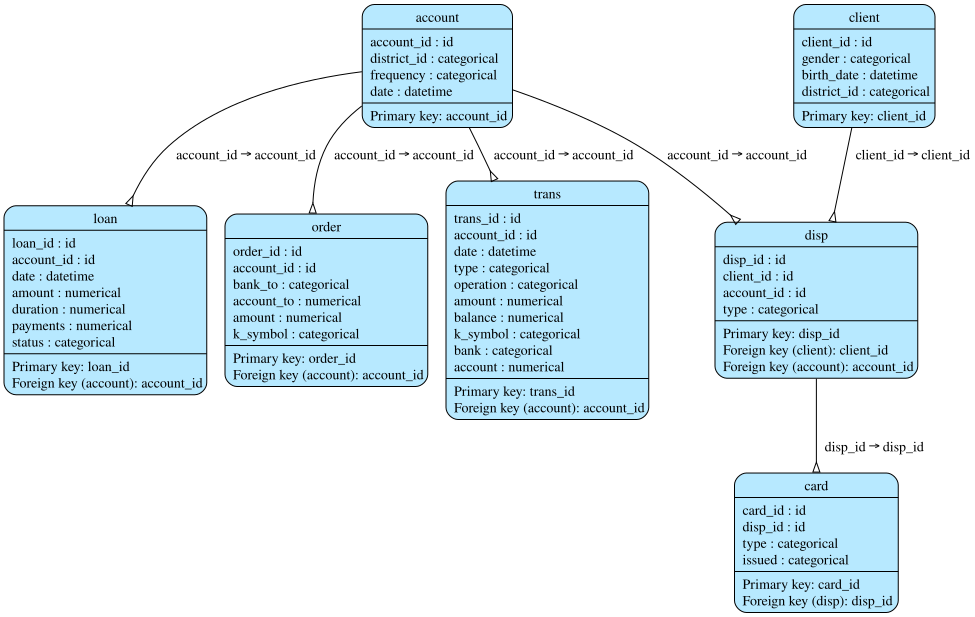

In [3]:
multi_metadata.visualize()

## Why a Random Subsample Isn't Enough

Let's  take a 10% random sample from all tables and then compare the overlap between the `account` and `loan` tables using the linked column.

Before:
- `real_data['account']:` 4500 rows
- `real_data['loan']`: 682 rows

After:
- `random_subset_real_data['account']`: 450 rows
- `random_subset_real_data['loan']`: 68 rows

When we compare values for the `account_id` columns in the random subset tables, only 4 of the 68 rows in the `random_subset_real_data['loan']` table match!

In [4]:
random_subset_real_data = {}

for table_name, table in real_data.items():
    row_sample_count = round(len(table) / 10)
    table = table.sample(n=row_sample_count, random_state=7).reset_index(drop=True)
    random_subset_real_data[table_name] = table

Let's inspect the data. First, the first few rows of the original `account` table:

In [5]:
real_data['account'].head(5)

,account_id,district_id,frequency,date
0,1,18,POPLATEK MESICNE,1995-03-24
1,2,1,POPLATEK MESICNE,1993-02-26
2,3,5,POPLATEK MESICNE,1997-07-07
3,4,12,POPLATEK MESICNE,1996-02-21
4,5,15,POPLATEK MESICNE,1997-05-30


And here are the first few rows after taking a 10% random sample.

In [6]:
random_subset_real_data['account'].head(5)

,account_id,district_id,frequency,date
0,378,68,POPLATEK MESICNE,1996-07-22
1,2122,68,POPLATEK MESICNE,1993-01-08
2,498,1,POPLATEK MESICNE,1993-11-21
3,2306,38,POPLATEK MESICNE,1993-12-08
4,1328,8,POPLATEK MESICNE,1996-05-04


Analyzing just 2 of the subsampled tables is enough to observe why this doesn't work: referential integrity is missing. The `account` and `loan` tables are linked together using the `account_id` column, with the `loan` table containing fewer rows (68 rows) than the `account` table (450 rows). Let's count the number of matching references between both of these columns and compare this to the full expected count.

In [7]:
random_subset_real_data['loan']['account_id'].isin(random_subset_real_data['account']['account_id']).sum()

np.int64(4)

And compare that against the total number of rows in the subsampled child table.

In [8]:
len(random_subset_real_data['loan'])

68

Out of 68 rows, it turns out that only 4 of the rows in the subsampled loan table have a corresponding `account_id` in the `account` table. For the rest of the loans, there are no associated `account_ids`. This breaks the referential integrity requirement, and makes it so that creating data with referential integrity would require dropping many of the rows in the loan table.

## Dropping Unknown References

To ensure that any random subsamples of our data maintain referential integrity, we have to remove all the rows that do not have a reference to their relevant primary key.

In SDV there is a relevant utility function called `drop_unknown_references()`. To use this function, we just need to pass in the multi-table data and our metadata to return a subsample containing no missing references. In our subsample, every child row will have a matching parent row.

> **For data to have referential integrity:**
> - Every child row in a child table must have a reference to a parent row.
> - Not every parent must have a child.

Let's use this function to drop missing references in our existing 10% subsample.

In [9]:
from sdv.utils import drop_unknown_references

cleaned_subsample = drop_unknown_references(
  random_subset_real_data, multi_metadata
)

Success! All foreign keys have referential integrity.

Table Name  # Rows (Original)  # Invalid Rows  # Rows (New)
   account                450               0           450
      card                 89              86             3
    client                537               0           537
      disp                537             489            48
      loan                 68              64             4
     order                647             572            75
     trans             105632           94836         10796

The function will output a data with referential integrity and also show the number of rows remaining in the new subsample:

As we can see, many rows in many tables were removed. The summary helps us understand which rows were removed in our subsample:

- The `client` and `account` tables are parent tables, so no rows were removed. Many of these rows may not have any data in the child tables, but the data is still referentially valid.
- In line with our earlier exploration, the `loan` table shrunk massively because only 4 rows had matching `account_id` values in the `account` subset.
- Other tables that have foreign key relationships with the `account` table also shrunk massively, including `disp`, `order`, and `trans`.

Ultimately, this suggests that the approach we took has some flaws. What if we wanted to preserve a certain percentage of rows for an important table? Pulling a random subset of data and then dropping rows with missing references to the parent tables makes it hard to control the amount of overall subsampled data that has referential integrity.

## Generating a Referentially Integral Subsample of your Data

We created the `get_random_subset()` utility function to help you create a random subsample of your data at the appropriate scale while maintaining referential integrity.

To use this function, you need to supply the name of the main table (`main_table_name`) you want to center your subsampling around, and the number of rows (`num_rows`) from that table that you want in the subsample. The SDV will then traverse the linked tables (parent and child tables) and extract rows such that the resulting multi-table data has referential integrity.

To really witness the power of this function, let's use the `account` table as our main table, since it has the most linked tables. Let's aim to select 45 rows from this table (1% of the rows), and have the SDV sample the remaining tables accordingly.

In [10]:
from sdv.utils import poc

main_table_rows = round(len(real_data['account']) / 10)

subsampled_data = poc.get_random_subset(
    real_data,
    multi_metadata,
    main_table_name="account",
    num_rows=main_table_rows
)

Success! Your subset has 89% less rows than the original.

Table Name  # Rows (Before)  # Rows (After)
   account             4500             450
      card              892              83
    client             5369            5369
      disp             5369             534
      loan              682              71
     order             6471             656
     trans          1056320          108843


The function will output some statistics about the subsample:

As expected, only 45 of the 4500 rows in the `account` table were kept. The linked tables were also greatly reduced in size in the subsample. Notice that, even with 45 rows in the `account` table, we have 7 entries in the `loan` table. Compare this with the previous example, where even with 450 rows in the `account` table we were left with just 4 entries in the `loan` table.

Our subsample was centered around a 1% sample of the `account` table. How do we know if 1% of our main table is enough? More broadly, how do we determine how much data is sufficient to subsample during our POC project with HMASynthesizer?

In Part B of this tutorial, we will explore how to answer this question. Continue to Part B here.

Our general advice is to cycle through the following steps until your quality is acceptable for the time it takes to generate the synthetic data:

1. Start with a small sample size of training data (e.g. 1%)
2. Train an HMASynthesizer model
3. Measure how long HMA took to train and synthesize
4. Evaluate the quality of the data

If you want higher quality and find the modeling and synthesis time acceptable, increase the sample size and run through steps 2 - 4 again. Let's run this process together with the same dataset so you can understand the ideal amount of data to use that balances time spent and quality. In part (b) of this tutorial we follow these steps above on the dataset we have.